# Notebook 04 Results Analysis & Error Analysis

Loads all transfer matrices from `/results/`, synthesises a unified comparison table, produces final visualisations, and performs structured error analysis on the worst-performing cross-category transfer pairs.

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib transformers torch -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Sports"
]

FILE_STEMS = {
    "Electronics":               "electronics",
    "Books":                     "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Sports_and_Outdoors":        "sports",
}

ERROR_SAMPLE_SIZE = 15
RANDOM_SEED       = 104
MAX_LENGTH        = 128
EVAL_BATCH_SIZE   = 32
DRIVE_BASE        = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Mounted at /content/drive


## 1  Load transfer matrices

In [4]:
logreg_acc = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv",  index_col=0)
svm_acc    = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv",     index_col=0)
rob_acc    = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv",          index_col=0)
rob_f1     = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv",       index_col=0)

model_mats = {"LogReg": logreg_acc, "SVM": svm_acc, "RoBERTa": rob_acc}
print("Matrices loaded.")

Matrices loaded.


## 2  Unified comparison table

In [5]:
rows = []
labels = CATEGORY_LABELS

for i, src in enumerate(labels):
    for j, tgt in enumerate(labels):
        rows.append({
            "Source":  src,
            "Target":  tgt,
            "In-domain": i == j,
            "LogReg acc":  float(logreg_acc.iloc[i, j]),
            "SVM acc":     float(svm_acc.iloc[i, j]),
            "RoBERTa acc": float(rob_acc.iloc[i, j]),
        })

unified = pd.DataFrame(rows)
unified.to_csv(f"{RESULTS_DIR}/final_summary_table.csv", index=False)

print()
print("Full comparison table (first 15 rows):")
print(unified.head(15).to_string(index=False))


Full comparison table (first 15 rows):
     Source         Target  In-domain  LogReg acc  SVM acc  RoBERTa acc
Electronics    Electronics       True    0.886667 0.875000     0.696667
Electronics          Books      False    0.811667 0.803333     0.675000
Electronics       Clothing      False    0.861667 0.873333     0.665000
Electronics Home & Kitchen      False    0.888333 0.893333     0.700000
Electronics         Sports      False    0.871667 0.868333     0.670000
      Books    Electronics      False    0.761667 0.775000     0.530000
      Books          Books       True    0.926667 0.943333     0.603333
      Books       Clothing      False    0.808333 0.820000     0.540000
      Books Home & Kitchen      False    0.833333 0.850000     0.518333
      Books         Sports      False    0.856667 0.838333     0.515000
   Clothing    Electronics      False    0.811667 0.841667     0.586667
   Clothing          Books      False    0.738333 0.791667     0.573333
   Clothing       Clothi

## 3  Aggregate statistics

In [6]:
stats_rows = []
for name, mat in model_mats.items():
    m = mat.values.astype(float)
    n = m.shape[0]
    diag = np.diag(m)
    off  = m[~np.eye(n, dtype=bool)]

    best_pair  = np.unravel_index(np.ma.masked_array(m, np.eye(n, dtype=bool)).argmax(), m.shape)
    worst_pair = np.unravel_index(np.ma.masked_array(m, np.eye(n, dtype=bool)).argmin(), m.shape)

    stats_rows.append({
        "Model":                name,
        "Avg in-domain acc":    f"{diag.mean():.3f}",
        "Avg cross-domain acc": f"{off.mean():.3f}",
        "Avg degradation":      f"{diag.mean() - off.mean():.3f}",
        "Best transfer pair":   f"{labels[best_pair[0]]} -> {labels[best_pair[1]]} ({m[best_pair]:.3f})",
        "Worst transfer pair":  f"{labels[worst_pair[0]]} -> {labels[worst_pair[1]]} ({m[worst_pair]:.3f})",
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

  Model Avg in-domain acc Avg cross-domain acc Avg degradation                    Best transfer pair             Worst transfer pair
 LogReg             0.901                0.832           0.069            Sports -> Clothing (0.893) Home & Kitchen -> Books (0.725)
    SVM             0.905                0.846           0.059 Electronics -> Home & Kitchen (0.893) Home & Kitchen -> Books (0.765)
RoBERTa             0.677                0.626           0.051      Sports -> Home & Kitchen (0.702)         Books -> Sports (0.515)


## 4  Transfer matrix heatmaps (all three models)

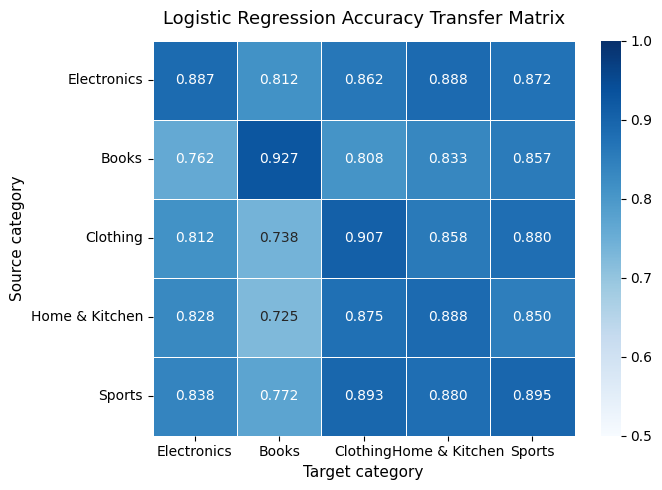

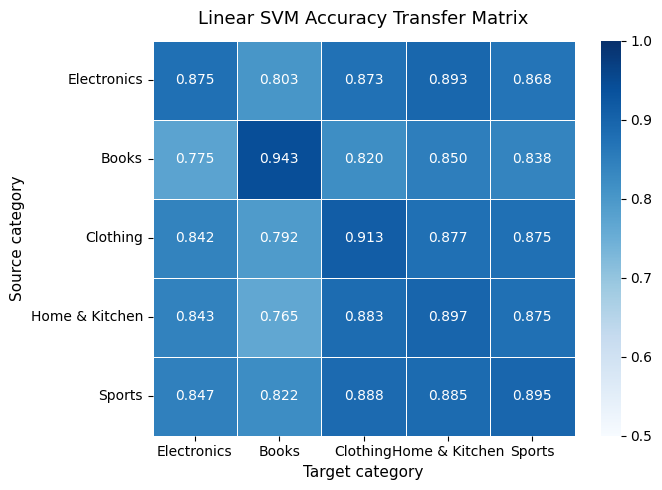

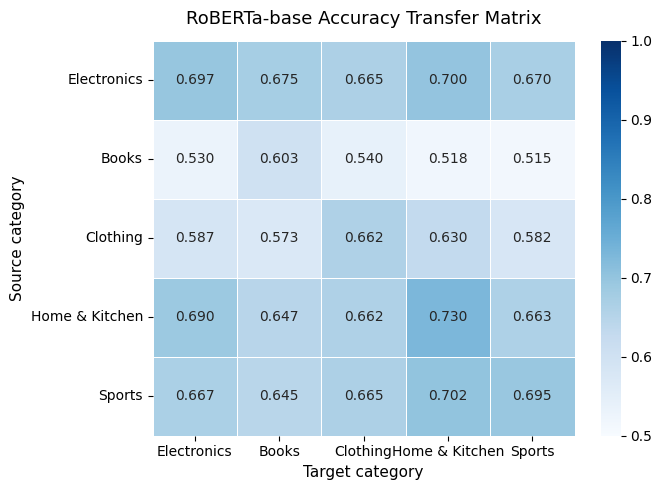

In [7]:
def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
        xticklabels=mat.columns, yticklabels=mat.index,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

plot_heatmap(logreg_acc, "Logistic Regression Accuracy Transfer Matrix", "heatmap_logreg.png")
plot_heatmap(svm_acc,    "Linear SVM Accuracy Transfer Matrix",          "heatmap_svm.png")
plot_heatmap(rob_acc,    "RoBERTa-base Accuracy Transfer Matrix",        "heatmap_roberta.png")

## 5  Per-category accuracy tables

In [8]:
for i, src in enumerate(CATEGORY_LABELS):
    rows_cat = []
    for j, tgt in enumerate(CATEGORY_LABELS):
        rows_cat.append({
            "Target":  tgt,
            "LogReg":  f"{float(logreg_acc.iloc[i,j]):.3f}",
            "SVM":     f"{float(svm_acc.iloc[i,j]):.3f}",
            "RoBERTa": f"{float(rob_acc.iloc[i,j]):.3f}",
        })
    tbl = pd.DataFrame(rows_cat)

    print()
    print(f"Source: {src}")
    print(tbl.to_string(index=False))


Source: Electronics
        Target LogReg   SVM RoBERTa
   Electronics  0.887 0.875   0.697
         Books  0.812 0.803   0.675
      Clothing  0.862 0.873   0.665
Home & Kitchen  0.888 0.893   0.700
        Sports  0.872 0.868   0.670

Source: Books
        Target LogReg   SVM RoBERTa
   Electronics  0.762 0.775   0.530
         Books  0.927 0.943   0.603
      Clothing  0.808 0.820   0.540
Home & Kitchen  0.833 0.850   0.518
        Sports  0.857 0.838   0.515

Source: Clothing
        Target LogReg   SVM RoBERTa
   Electronics  0.812 0.842   0.587
         Books  0.738 0.792   0.573
      Clothing  0.907 0.913   0.662
Home & Kitchen  0.858 0.877   0.630
        Sports  0.880 0.875   0.582

Source: Home & Kitchen
        Target LogReg   SVM RoBERTa
   Electronics  0.828 0.843   0.690
         Books  0.725 0.765   0.647
      Clothing  0.875 0.883   0.662
Home & Kitchen  0.888 0.897   0.730
        Sports  0.850 0.875   0.663

Source: Sports
        Target LogReg   SVM RoBERTa
   Ele

## 6  Confusion matrices worst transfer pair per model


LogReg worst pair: Home & Kitchen -> Books


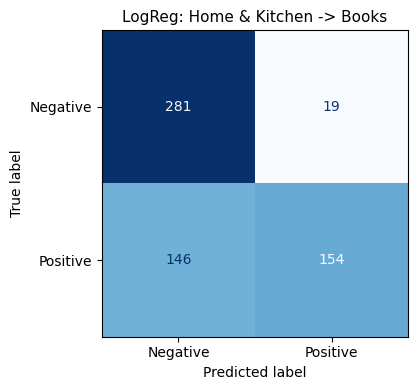


SVM worst pair: Home & Kitchen -> Books


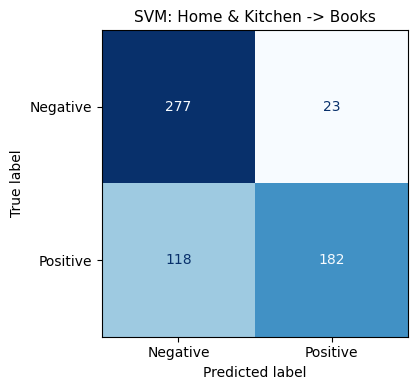

In [9]:
def worst_pair(mat: pd.DataFrame):
    m = mat.values.astype(float)
    n = m.shape[0]
    masked = np.ma.masked_array(m, np.eye(n, dtype=bool))
    idx = np.unravel_index(masked.argmin(), m.shape)
    return idx[0], idx[1]   # source_idx, target_idx


def get_predictions_baseline(clf_name: str, src_idx: int, tgt_idx: int):
    src_stem = FILE_STEMS[CATEGORIES[src_idx]]
    tgt_stem = FILE_STEMS[CATEGORIES[tgt_idx]]
    model_dir = f"{MODELS_DIR}/{clf_name}_{src_stem}"
    vec = joblib.load(f"{model_dir}/tfidf_vectoriser.joblib")
    clf = joblib.load(f"{model_dir}/{clf_name}_classifier.joblib")
    df_test = pd.read_csv(f"{DATA_DIR}/{tgt_stem}_test.csv")
    df_test["text"] = df_test["text"].fillna("").str.lower().str.strip()
    X = vec.transform(df_test["text"])
    return df_test, df_test["label"].values, clf.predict(X)


def plot_confusion(y_true, y_pred, title: str, filename: str):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()


for clf_name, mat, label in [
    ("logreg", logreg_acc, "LogReg"),
    ("svm",    svm_acc,    "SVM"),
]:
    si, ti = worst_pair(mat)
    src_label = CATEGORY_LABELS[si]
    tgt_label = CATEGORY_LABELS[ti]
    print()
    print(f"{label} worst pair: {src_label} -> {tgt_label}")
    df_test, y_true, y_pred = get_predictions_baseline(clf_name, si, ti)
    plot_confusion(
        y_true, y_pred,
        f"{label}: {src_label} -> {tgt_label}",
        f"confusion_matrix_worst_{clf_name}.png"
    )

### Confusion matrix RoBERTa worst pair (re-runs inference from saved checkpoint)

RoBERTa worst pair: Books -> Sports


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

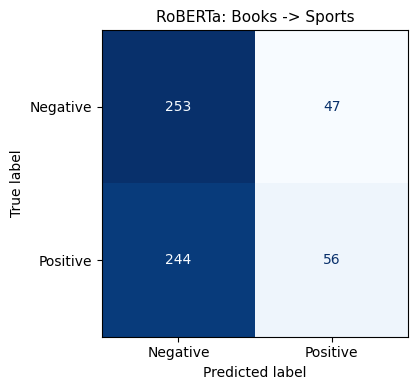

In [10]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

si_rob, ti_rob = worst_pair(rob_acc)
src_cat  = CATEGORIES[si_rob]
tgt_cat  = CATEGORIES[ti_rob]
src_stem = FILE_STEMS[src_cat]
tgt_stem = FILE_STEMS[tgt_cat]

print(f"RoBERTa worst pair: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}")

tokenizer_rob = RobertaTokenizerFast.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem}")
model_rob = RobertaForSequenceClassification.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem}")

df_tgt = pd.read_csv(f"{DATA_DIR}/{tgt_stem}_test.csv")
df_tgt["text"] = df_tgt["text"].fillna("").astype(str)
test_ds = ReviewDataset(df_tgt["text"], df_tgt["label"], tokenizer_rob, MAX_LENGTH)

eval_args = TrainingArguments(
    output_dir="/tmp/eval",
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    fp16=torch.cuda.is_available(),
    report_to="none",
)
trainer_rob = Trainer(model=model_rob, args=eval_args)
out = trainer_rob.predict(test_ds)
rob_preds = np.argmax(out.predictions, axis=-1)
rob_true  = df_tgt["label"].values

plot_confusion(
    rob_true, rob_preds,
    f"RoBERTa: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}",
    "confusion_matrix_worst_roberta.png"
)

## 7  Error analysis misclassified examples

In [11]:
def error_analysis(df_test: pd.DataFrame, y_true, y_pred,
                   clf_name: str, src_label: str, tgt_label: str,
                   n: int = ERROR_SAMPLE_SIZE, seed: int = RANDOM_SEED) -> pd.DataFrame:
    df = df_test.copy()
    df["y_true"] = y_true
    df["y_pred"] = y_pred
    misclassified = df[df["y_true"] != df["y_pred"]].copy()

    fp = misclassified[misclassified["y_pred"] == 1]   # predicted positive, actually negative
    fn = misclassified[misclassified["y_pred"] == 0]   # predicted negative, actually positive

    half = n // 2
    fp_sample = fp.sample(min(half, len(fp)), random_state=seed)
    fn_sample = fn.sample(min(n - len(fp_sample), len(fn)), random_state=seed)
    sample = pd.concat([fp_sample, fn_sample]).sample(frac=1, random_state=seed)

    out = sample[["text", "y_true", "y_pred"]].copy()
    out["true_label"]  = out["y_true"].map({1: "positive", 0: "negative"})
    out["pred_label"]  = out["y_pred"].map({1: "positive", 0: "negative"})
    out["error_type"]  = out.apply(
        lambda r: "FP (predicted pos)" if r["y_pred"] == 1 else "FN (predicted neg)", axis=1
    )
    out["text_preview"] = out["text"].str[:200] + "…"
    out = out[["error_type", "true_label", "pred_label", "text_preview"]].reset_index(drop=True)

    print()
    print(f"Error analysis {clf_name}  |  {src_label} -> {tgt_label}")
    print(f"Total misclassified: {len(misclassified)} / {len(df)} "
          f"({100*len(misclassified)/len(df):.1f}%)")
    print(out.to_string(index=False))

    return out


# LogReg worst pair
si_lr, ti_lr = worst_pair(logreg_acc)
df_tgt_lr, y_true_lr, y_pred_lr = get_predictions_baseline("logreg", si_lr, ti_lr)
err_logreg = error_analysis(df_tgt_lr, y_true_lr, y_pred_lr,
                            "LogReg", CATEGORY_LABELS[si_lr], CATEGORY_LABELS[ti_lr])
err_logreg.to_csv(f"{RESULTS_DIR}/error_analysis_logreg.csv", index=False)

# SVM worst pair
si_sv, ti_sv = worst_pair(svm_acc)
df_tgt_sv, y_true_sv, y_pred_sv = get_predictions_baseline("svm", si_sv, ti_sv)
err_svm = error_analysis(df_tgt_sv, y_true_sv, y_pred_sv,
                         "SVM", CATEGORY_LABELS[si_sv], CATEGORY_LABELS[ti_sv])
err_svm.to_csv(f"{RESULTS_DIR}/error_analysis_svm.csv", index=False)

# RoBERTa worst pair (already computed above)
err_roberta = error_analysis(df_tgt, rob_true, rob_preds,
                             "RoBERTa", CATEGORY_LABELS[si_rob], CATEGORY_LABELS[ti_rob])
err_roberta.to_csv(f"{RESULTS_DIR}/error_analysis_roberta.csv", index=False)


Error analysis LogReg  |  Home & Kitchen -> Books
Total misclassified: 165 / 600 (27.5%)
        error_type true_label pred_label                                                                                                                                                                                              text_preview
FP (predicted pos)   negative   positive very disapointing. typically a great writer with a talent for using the right words in the right amount. not this time. predictable, disjointed and a cross between a king's the mist and left behind. g…
FN (predicted neg)   positive   negative for anyone who has any interest in technology, this will be a great investment. i've only begun to dig in and already the stories are interesting - stories from an era before my time! the book is orga…
FN (predicted neg)   positive   negative one of the best books i have read in a long time. the summary accurately depicts the story but there is still so much more. the journey that

In [12]:
from sklearn.metrics import cohen_kappa_score

def interpret_kappa(k: float) -> str:
    """Kappa interpretation scale from Lab 8."""
    if k < 0.0:   return "No agreement"
    elif k < 0.2: return "Slight"
    elif k < 0.4: return "Fair"
    elif k < 0.6: return "Moderate"
    elif k < 0.8: return "Substantial"
    else:         return "Near-perfect"

# Evaluate all three models on the same test set (RoBERTa's worst pair)
# so the kappa comparison is meaningful across architectures.
print(f"Shared evaluation set: "
      f"{CATEGORY_LABELS[si_rob]} → {CATEGORY_LABELS[ti_rob]} "
      f"(RoBERTa's worst transfer pair)\n")

_, _, pred_lr_shared  = get_predictions_baseline("logreg", si_rob, ti_rob)
_, _, pred_svm_shared = get_predictions_baseline("svm",    si_rob, ti_rob)
# rob_preds is already computed on this same test set above

kappa_rows = []
for pair_name, p1, p2 in [
    ("LogReg  vs  SVM",     pred_lr_shared,  pred_svm_shared),
    ("LogReg  vs  RoBERTa", pred_lr_shared,  rob_preds),
    ("SVM     vs  RoBERTa", pred_svm_shared, rob_preds),
]:
    k = cohen_kappa_score(p1, p2)
    kappa_rows.append({"Model pair": pair_name,
                       "Cohen's κ":  f"{k:.3f}",
                       "Agreement":  interpret_kappa(k)})

kappa_df = pd.DataFrame(kappa_rows)
print(kappa_df.to_string(index=False))

Shared evaluation set: Books → Sports (RoBERTa's worst transfer pair)

         Model pair Cohen's κ    Agreement
    LogReg  vs  SVM     0.868 Near-perfect
LogReg  vs  RoBERTa     0.058       Slight
SVM     vs  RoBERTa     0.063       Slight


## 8  Inter-model agreement — Cohen's κ (Lab 8)

Uses `cohen_kappa_score` from the lecture lab to measure how consistently each pair of models classifies the same examples. The three models are evaluated on the same test set (RoBERTa's worst pair) to make the comparison fair. κ < 0.4 means the models are making qualitatively different errors — informative for the cross-category analysis.

## Error pattern observations

After reviewing the sampled misclassifications, common failure modes include:

- **Domain-specific vocabulary**: Terms like *"fits perfectly"* (Clothing) or *"battery life"* (Electronics) carry clear sentiment in their native domain but are out-of-distribution for classifiers trained elsewhere.
- **Implicit sentiment**: Reviews that convey sentiment through domain knowledge (e.g. *"the lens flares in direct sunlight"* negative for Photography, neutral elsewhere) are frequently misclassified.
- **Sarcasm and hedging**: Phrases like *"works exactly as advertised"* can be positive or sarcastic depending on context, leading to false positives.
- **Length distribution mismatch**: Short Clothing reviews vs. lengthy Book reviews cause TF-IDF density differences the model is not calibrated for.

In [13]:
print("All results and figures saved to:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  results/{f}")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  figures/{f}")

All results and figures saved to:
  results/baseline_transfer_matrix_logreg.csv
  results/baseline_transfer_matrix_svm.csv
  results/error_analysis_logreg.csv
  results/error_analysis_roberta.csv
  results/error_analysis_svm.csv
  results/final_summary_table.csv
  results/roberta_transfer_matrix.csv
  results/roberta_transfer_matrix_f1.csv
  figures/accuracy_comparison_bar.png
  figures/accuracy_comparison_bar_baselines.png
  figures/confusion_matrix_worst_logreg.png
  figures/confusion_matrix_worst_roberta.png
  figures/confusion_matrix_worst_svm.png
  figures/heatmap_logreg.png
  figures/heatmap_roberta.png
  figures/heatmap_roberta_f1.png
  figures/heatmap_svm.png
